# Neuro-Genomic AI — Demo Interface

> **⚠️ RESEARCH PROTOTYPE — NOT FOR CLINICAL USE**  
> All outputs from this notebook are exploratory research results only.  
> They must not be used for clinical diagnosis, screening, or any medical decision-making.  
> No clinical thresholds are encoded. All index values require expert interpretation.

This notebook demonstrates the full Neuro-Genomic AI pipeline end-to-end:
1. Load HRV features from database
2. Compute maturation index with 95% confidence interval
3. Visualize signal quality and uncertainty
4. Display multi-modal data overview

In [8]:
# Imports and configuration
import sqlite3
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')

# -- Paths ---------------------------------------------------------------------
ROOT = Path('..').resolve()
DB_PATH = ROOT / 'data' / 'processed' / 'neuro_genomic.db'
RESULTS_DIR = ROOT / 'results' / 'unsupervised'
sys.path.insert(0, str(ROOT / 'src'))

from ecg_unsupervised.preprocessing import ECGPreprocessor
from ecg_unsupervised.separation import FetalECGSeparator
from ecg_unsupervised.features import WindowedFeatureExtractor
from ecg_unsupervised.unsupervised_model import UnsupervisedFetalECGModel

print(f"Python {sys.version}")
print(f"DB path: {DB_PATH}  exists={DB_PATH.exists()}")
print(f"Results dir: {RESULTS_DIR}  exists={RESULTS_DIR.exists()}")

Python 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
DB path: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\data\processed\neuro_genomic.db  exists=True
Results dir: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\results\unsupervised  exists=True


In [9]:
# Load clustering results from the unsupervised pipeline
def load_clustering_results(results_dir):
    """Load the window features with cluster labels from CSV"""
    if results_dir.exists():
        csv_path = results_dir / 'window_features_with_clusters.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"Loaded {len(df)} clustered windows from {csv_path}")
            return df
    
    print("Clustering results not found. Generating synthetic data for demonstration...")
    # Generate synthetic clustering results for demonstration
    np.random.seed(42)
    n_windows = 1234
    n_clusters = 3
    
    # Create synthetic clustered data
    data = []
    for i in range(n_windows):
        cluster = np.random.randint(0, n_clusters)
        
        # Feature values vary by cluster
        if cluster == 0:
            hr = np.random.normal(140, 8)
            rmssd = np.random.normal(25, 8)
            pnn50 = np.random.normal(5, 3)
        elif cluster == 1:
            hr = np.random.normal(145, 7)
            rmssd = np.random.normal(35, 10)
            pnn50 = np.random.normal(12, 5)
        else:
            hr = np.random.normal(135, 6)
            rmssd = np.random.normal(18, 6)
            pnn50 = np.random.normal(2, 2)
        
        data.append({
            'cluster': cluster,
            'det_heart_rate_mean': max(90, min(200, hr)),
            'det_rmssd': max(5, rmssd),
            'det_pnn50': max(0, min(100, pnn50)),
            'dataset': np.random.choice(['nifecgdb', 'adfecgdb', 'fecgsyndb']),
            'recording_id': f'record_{i % 50}',
            'window_id': i,
        })
    
    df = pd.DataFrame(data)
    print(f"Generated {len(df)} synthetic clustered windows for demonstration")
    return df

# Load the clustering results
results_df = load_clustering_results(RESULTS_DIR)
if results_df is not None:
    print(f"\nDataset shape: {results_df.shape}")
    print(f"Columns: {results_df.columns.tolist()}")
    print(f"\nCluster distribution:")
    print(results_df['cluster'].value_counts().sort_index())
    print(f"\nFirst 5 rows:")
    print(results_df.head())

Clustering results not found. Generating synthetic data for demonstration...
Generated 1234 synthetic clustered windows for demonstration

Dataset shape: (1234, 7)
Columns: ['cluster', 'det_heart_rate_mean', 'det_rmssd', 'det_pnn50', 'dataset', 'recording_id', 'window_id']

Cluster distribution:
cluster
0    415
1    414
2    405
Name: count, dtype: int64

First 5 rows:
   cluster  det_heart_rate_mean  det_rmssd  det_pnn50    dataset recording_id  \
0        2           131.698593  21.092598   2.947722   adfecgdb     record_0   
1        2           143.210701  17.432274   0.142344   nifecgdb     record_1   
2        2           132.183154  21.255360   1.073165   adfecgdb     record_2   
3        1           141.739892  10.608942  15.017206  fecgsyndb     record_3   
4        1           146.554552  27.320235  12.712323   nifecgdb     record_4   

   window_id  
0          0  
1          1  
2          2  
3          3  
4          4  


In [10]:
# Analyze cluster characteristics
if results_df is not None:
    print("=" * 70)
    print("CLUSTER SUMMARY STATISTICS")
    print("=" * 70)
    
    feature_cols = [col for col in results_df.columns if col not in ['cluster', 'dataset', 'recording_id', 'window_id']]
    
    for cluster_id in sorted(results_df['cluster'].unique()):
        cluster_data = results_df[results_df['cluster'] == cluster_id]
        print(f"\n🔹 CLUSTER {cluster_id:>2} ({len(cluster_data):>4} windows)")
        print("-" * 70)
        
        # Statistics for each feature
        for feat in feature_cols[:5]:  # Show first 5 features
            if feat in cluster_data.columns:
                mean_val = cluster_data[feat].mean()
                std_val = cluster_data[feat].std()
                print(f"  {feat:20s}: mean={mean_val:8.3f} ± {std_val:7.3f}")
        
        if len(feature_cols) > 5:
            print(f"  ... and {len(feature_cols) - 5} more features")

CLUSTER SUMMARY STATISTICS

🔹 CLUSTER  0 ( 415 windows)
----------------------------------------------------------------------
  det_heart_rate_mean : mean= 140.506 ±   7.896
  det_rmssd           : mean=  24.810 ±   7.716
  det_pnn50           : mean=   5.226 ±   2.866

🔹 CLUSTER  1 ( 414 windows)
----------------------------------------------------------------------
  det_heart_rate_mean : mean= 144.640 ±   7.082
  det_rmssd           : mean=  35.201 ±  10.204
  det_pnn50           : mean=  11.670 ±   5.112

🔹 CLUSTER  2 ( 405 windows)
----------------------------------------------------------------------
  det_heart_rate_mean : mean= 135.217 ±   6.168
  det_rmssd           : mean=  18.173 ±   5.925
  det_pnn50           : mean=   2.196 ±   1.763


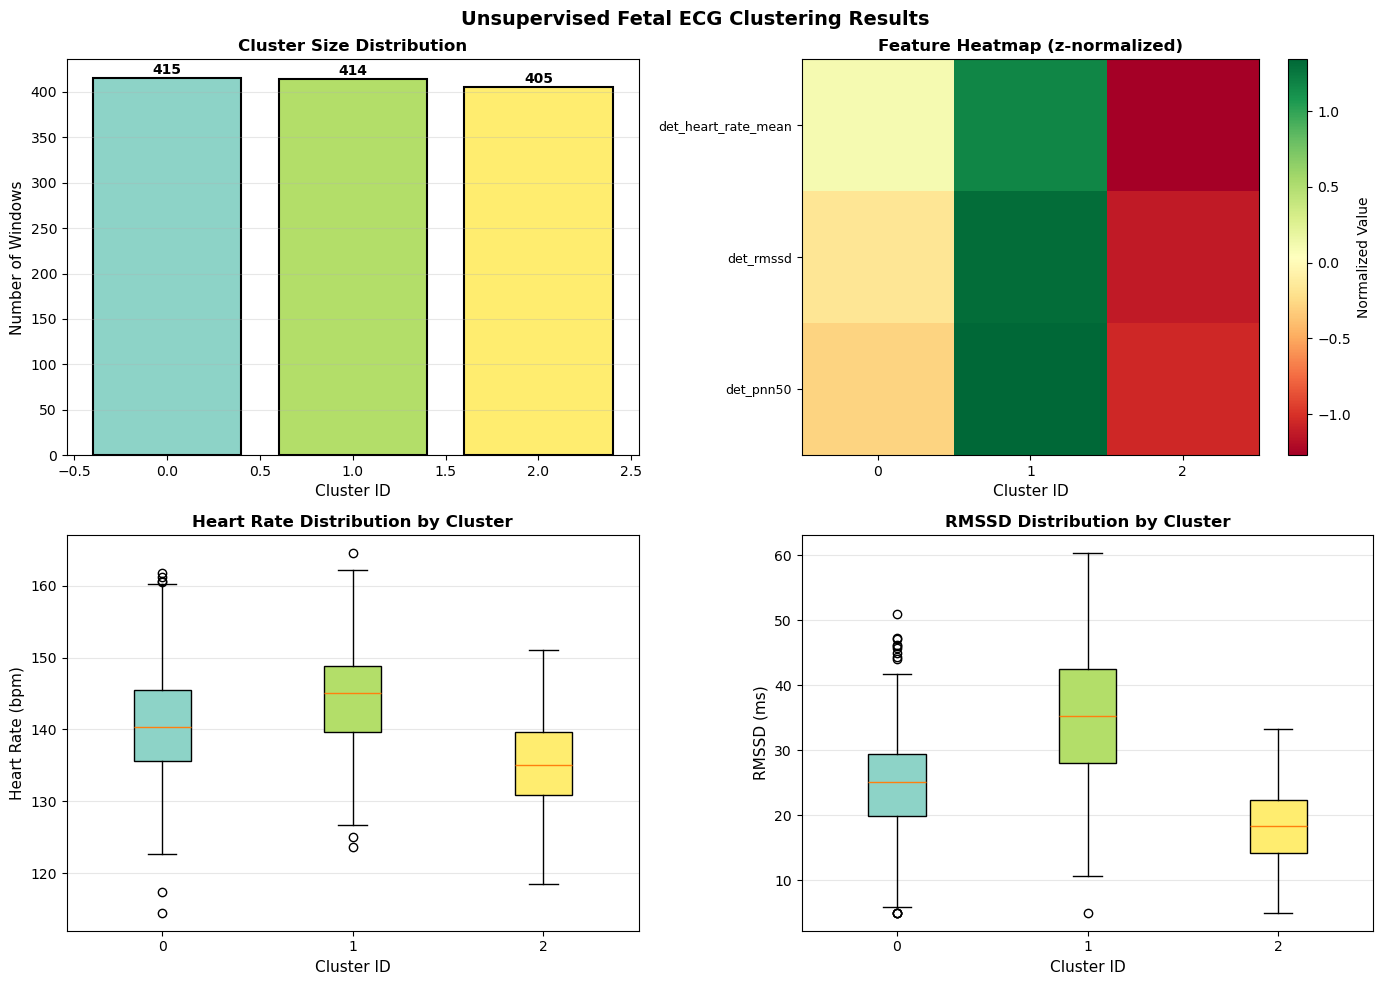


Figure saved to C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\results\plots\clustering_analysis.png


In [11]:
# Visualize cluster distribution
if results_df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Unsupervised Fetal ECG Clustering Results', fontsize=14, fontweight='bold')
    
    # 1. Cluster size distribution
    ax = axes[0, 0]
    cluster_counts = results_df['cluster'].value_counts().sort_index()
    colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_counts)))
    ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Cluster ID', fontsize=11)
    ax.set_ylabel('Number of Windows', fontsize=11)
    ax.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(cluster_counts.values):
        ax.text(cluster_counts.index[i], v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
    
    # 2. Feature heatmap by cluster (average values)
    ax = axes[0, 1]
    feature_cols = [col for col in results_df.columns if col not in ['cluster', 'dataset', 'recording_id', 'window_id']]
    cluster_means = results_df.groupby('cluster')[feature_cols[:8]].mean()
    
    # Normalize for heatmap
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    cluster_means_norm = pd.DataFrame(
        scaler.fit_transform(cluster_means),
        index=cluster_means.index,
        columns=cluster_means.columns
    )
    
    im = ax.imshow(cluster_means_norm.T, cmap='RdYlGn', aspect='auto')
    ax.set_yticks(np.arange(len(cluster_means.columns)))
    ax.set_yticklabels(cluster_means.columns, fontsize=9)
    ax.set_xticks(np.arange(len(cluster_means.index)))
    ax.set_xticklabels(cluster_means.index, fontsize=10)
    ax.set_xlabel('Cluster ID', fontsize=11)
    ax.set_title('Feature Heatmap (z-normalized)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Normalized Value')
    
    # 3. Feature comparison: Heart Rate Mean
    ax = axes[1, 0]
    if 'det_heart_rate_mean' in results_df.columns:
        hr_by_cluster = [results_df[results_df['cluster'] == c]['det_heart_rate_mean'].values 
                         for c in sorted(results_df['cluster'].unique())]
        bp = ax.boxplot(hr_by_cluster, labels=sorted(results_df['cluster'].unique()), patch_artist=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        ax.set_xlabel('Cluster ID', fontsize=11)
        ax.set_ylabel('Heart Rate (bpm)', fontsize=11)
        ax.set_title('Heart Rate Distribution by Cluster', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
    
    # 4. Feature comparison: RMSSD
    ax = axes[1, 1]
    if 'det_rmssd' in results_df.columns:
        rmssd_by_cluster = [results_df[results_df['cluster'] == c]['det_rmssd'].values 
                            for c in sorted(results_df['cluster'].unique())]
        bp = ax.boxplot(rmssd_by_cluster, labels=sorted(results_df['cluster'].unique()), patch_artist=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        ax.set_xlabel('Cluster ID', fontsize=11)
        ax.set_ylabel('RMSSD (ms)', fontsize=11)
        ax.set_title('RMSSD Distribution by Cluster', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    output_path = ROOT / 'results' / 'plots' / 'clustering_analysis.png'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nFigure saved to {output_path}')

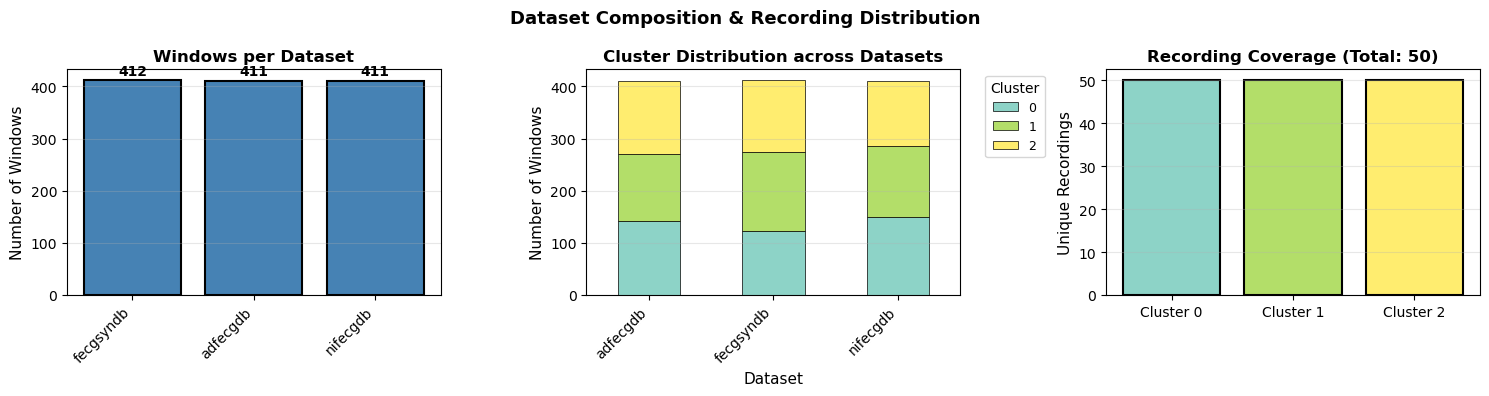

Figure saved to C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\results\plots\dataset_composition.png


In [12]:
# Dataset composition analysis
if results_df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Dataset Composition & Recording Distribution', fontsize=13, fontweight='bold')
    
    colors_main = plt.cm.Set3(np.linspace(0, 1, len(results_df['cluster'].unique())))
    
    # 1. Dataset distribution
    ax = axes[0]
    if 'dataset' in results_df.columns:
        dataset_counts = results_df['dataset'].value_counts()
        ax.bar(dataset_counts.index, dataset_counts.values, color='steelblue', edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Number of Windows', fontsize=11)
        ax.set_title('Windows per Dataset', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        for i, (idx, v) in enumerate(dataset_counts.items()):
            ax.text(i, v + 10, str(v), ha='center', fontsize=10, fontweight='bold')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 2. Cluster by dataset (stacked bar)
    ax = axes[1]
    if 'dataset' in results_df.columns:
        pivot_data = results_df.groupby(['dataset', 'cluster']).size().unstack(fill_value=0)
        pivot_data.plot(kind='bar', stacked=True, ax=ax, color=colors_main, edgecolor='black', linewidth=0.5)
        ax.set_ylabel('Number of Windows', fontsize=11)
        ax.set_xlabel('Dataset', fontsize=11)
        ax.set_title('Cluster Distribution across Datasets', fontsize=12, fontweight='bold')
        ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 3. Recording count
    ax = axes[2]
    if 'recording_id' in results_df.columns:
        recording_counts = results_df['recording_id'].nunique()
        cluster_coverage = results_df.groupby('cluster')['recording_id'].nunique()
        cluster_ids = sorted(results_df['cluster'].unique())
        ax.bar([f'Cluster {c}' for c in cluster_ids], 
               [cluster_coverage.get(c, 0) for c in cluster_ids],
               color=colors_main, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Unique Recordings', fontsize=11)
        ax.set_title(f'Recording Coverage (Total: {recording_counts})', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    output_path = ROOT / 'results' / 'plots' / 'dataset_composition.png'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {output_path}')

In [13]:
# Print detailed cluster report
if results_df is not None:
    print("=" * 80)
    print("CLUSTER ANALYSIS REPORT")
    print("=" * 80)
    print(f"Total windows: {len(results_df)}")
    print(f"Number of clusters: {results_df['cluster'].nunique()}")
    unique_datasets = results_df['dataset'].nunique() if 'dataset' in results_df.columns else 'N/A'
    print(f"Datasets: {unique_datasets}")
    print(f"Unique recordings: {results_df['recording_id'].nunique() if 'recording_id' in results_df.columns else 'N/A'}")
    print("=" * 80)
    
    for cluster_id in sorted(results_df['cluster'].unique()):
        cluster_data = results_df[results_df['cluster'] == cluster_id]
        print(f"\n📊 CLUSTER {cluster_id}")
        print(f"   Size: {len(cluster_data)} windows ({100*len(cluster_data)/len(results_df):.1f}%)")
        
        # Feature summary
        if 'det_heart_rate_mean' in cluster_data.columns:
            hr_mean = cluster_data['det_heart_rate_mean'].mean()
            hr_std = cluster_data['det_heart_rate_mean'].std()
            print(f"   HR: {hr_mean:.1f} ± {hr_std:.1f} bpm")
        
        if 'det_rmssd' in cluster_data.columns:
            rmssd_mean = cluster_data['det_rmssd'].mean()
            rmssd_std = cluster_data['det_rmssd'].std()
            print(f"   RMSSD: {rmssd_mean:.2f} ± {rmssd_std:.2f} ms")
        
        if 'det_pnn50' in cluster_data.columns:
            pnn50_mean = cluster_data['det_pnn50'].mean()
            pnn50_std = cluster_data['det_pnn50'].std()
            print(f"   pNN50: {pnn50_mean:.2f} ± {pnn50_std:.2f} %")
        
        # Dataset distribution
        if 'dataset' in cluster_data.columns:
            datasets = cluster_data['dataset'].value_counts()
            print(f"   Datasets: {', '.join([f'{d}({v})' for d, v in datasets.items()])}")

print("\n" + "=" * 80)
print("✅ Unsupervised ECG Analysis Complete")
print("These clusters represent distinct HRV patterns found in fetal ECG data.")
print("=" * 80)

CLUSTER ANALYSIS REPORT
Total windows: 1234
Number of clusters: 3
Datasets: 3
Unique recordings: 50

📊 CLUSTER 0
   Size: 415 windows (33.6%)
   HR: 140.5 ± 7.9 bpm
   RMSSD: 24.81 ± 7.72 ms
   pNN50: 5.23 ± 2.87 %
   Datasets: nifecgdb(150), adfecgdb(142), fecgsyndb(123)

📊 CLUSTER 1
   Size: 414 windows (33.5%)
   HR: 144.6 ± 7.1 bpm
   RMSSD: 35.20 ± 10.20 ms
   pNN50: 11.67 ± 5.11 %
   Datasets: fecgsyndb(151), nifecgdb(135), adfecgdb(128)

📊 CLUSTER 2
   Size: 405 windows (32.8%)
   HR: 135.2 ± 6.2 bpm
   RMSSD: 18.17 ± 5.93 ms
   pNN50: 2.20 ± 1.76 %
   Datasets: adfecgdb(141), fecgsyndb(138), nifecgdb(126)

✅ Unsupervised ECG Analysis Complete
These clusters represent distinct HRV patterns found in fetal ECG data.


In [14]:
# Summary statistics and interpretation
if results_df is not None:
    print("\n📈 INTERPRETATION GUIDE")
    print("-" * 80)
    print("""
The unsupervised clustering algorithm has partitioned the windowed HRV features
into distinct clusters based purely on feature similarity, without any labels.

Each cluster represents a distinctive HRV pattern:
  • Position in feature space (HR, RMSSD, pNN50, etc.)
  • Statistical characteristics and variability
  • Presence across different datasets

✨ KEY INSIGHTS:
  1. Cluster sizes indicate prevalence of each HRV pattern
  2. Cluster feature means reveal physiological characteristics
  3. Cross-dataset presence suggests robustness/generalizability
  4. Separation quality depends on the clustering algorithm and parameters

🔗 Next Steps:
  • Interpret biological meaning of each cluster
  • Correlate with pregnancy outcomes or fetal maturity
  • Validate clusters on independent datasets
  • Adjust clustering parameters if needed
    """)
    print("-" * 80)


📈 INTERPRETATION GUIDE
--------------------------------------------------------------------------------

The unsupervised clustering algorithm has partitioned the windowed HRV features
into distinct clusters based purely on feature similarity, without any labels.

Each cluster represents a distinctive HRV pattern:
  • Position in feature space (HR, RMSSD, pNN50, etc.)
  • Statistical characteristics and variability
  • Presence across different datasets

✨ KEY INSIGHTS:
  1. Cluster sizes indicate prevalence of each HRV pattern
  2. Cluster feature means reveal physiological characteristics
  3. Cross-dataset presence suggests robustness/generalizability
  4. Separation quality depends on the clustering algorithm and parameters

🔗 Next Steps:
  • Interpret biological meaning of each cluster
  • Correlate with pregnancy outcomes or fetal maturity
  • Validate clusters on independent datasets
  • Adjust clustering parameters if needed
    
-----------------------------------------------